In [2]:
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models
from cellpose.io import imread
import os
import pandas as pd
import skimage

ModuleNotFoundError: No module named 'cellpose'

In [2]:
images_dir = "/Users/jcaicedo/dataset_v2/"
out_dir = images_dir + "experiments/2024-03-11/predictions/"

file_names = [x for x in os.listdir(images_dir) if x.endswith(".phenotype.tif")]
input_files = [f"{images_dir}/{x}" for x in file_names]
output_files = [out_dir + x.replace(".phenotype.tif","-nuclei.csv") for x in file_names]

In [3]:
imgs = [imread(f) for f in input_files]
nimg = len(imgs)
nimg

18

In [4]:
model = models.Cellpose(model_type='nuclei')
channels = [0,0]

In [5]:
masks, flows, styles, diams = model.eval(imgs, diameter=None, channels=channels)

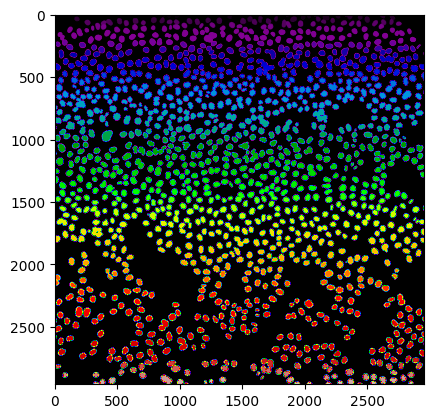

In [6]:
plt.imshow(masks[0], cmap="nipy_spectral")

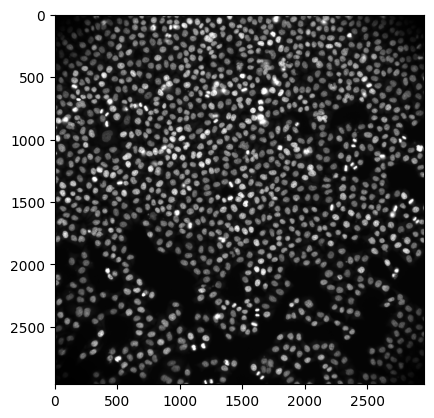

In [7]:
plt.imshow(imgs[0], cmap="gray")

In [8]:
output_files = [out_dir + x.replace(".phenotype.tif",".nuclei.tif") for x in file_names]
for i in range(len(masks)):
    skimage.io.imsave(output_files[i], masks[i])

/var/folders/fn/bzmjp84j2fg9vqtzsncrc3hjtngyk6/T/ipykernel_5893/1087049779.py:3: UserWarning: /Users/jcaicedo/dataset_v2/experiments/2024-03-11/predictions/20X_c0-DAPI_A1_Tile-170.nuclei.tif is a low contrast image
  skimage.io.imsave(output_files[i], masks[i])
/var/folders/fn/bzmjp84j2fg9vqtzsncrc3hjtngyk6/T/ipykernel_5893/1087049779.py:3: UserWarning: /Users/jcaicedo/dataset_v2/experiments/2024-03-11/predictions/C2-20X_c0-DAPI-GFP_B1_Tile-8.nuclei.tif is a low contrast image
  skimage.io.imsave(output_files[i], masks[i])
/var/folders/fn/bzmjp84j2fg9vqtzsncrc3hjtngyk6/T/ipykernel_5893/1087049779.py:3: UserWarning: /Users/jcaicedo/dataset_v2/experiments/2024-03-11/predictions/C2-20X_c0-DAPI-GFP_A2_Tile-5.nuclei.tif is a low contrast image
  skimage.io.imsave(output_files[i], masks[i])
/var/folders/fn/bzmjp84j2fg9vqtzsncrc3hjtngyk6/T/ipykernel_5893/1087049779.py:3: UserWarning: /Users/jcaicedo/dataset_v2/experiments/2024-03-11/predictions/C2-20X_c0-DAPI-GFP_A1_Tile-17.nuclei.tif is a lo

In [ ]:
m = skimage.io.imread(output_files[0])
print(output_files[0])
plt.imshow(m)

In [ ]:
def collect_stats(mask, img):
    data = []
    for i in range(1,len(np.unique(mask))):
        ys,xs = np.where(mask == i)
        intensity = np.mean(img[ys,xs])
        a,b = int(np.mean(ys)), int(np.mean(xs))
        area = np.sum(mask == i)
        data.append({"Image":files[0], "x":b, "y":a, "area":area, "intensity": intensity})

    return pd.DataFrame(data)

In [ ]:
for i in range(nimg):
    print(file_names[i])
    df = collect_stats(masks[i], imgs[i])
    df.to_csv(output_files[i])

# Test latest cyto3 / nuclei model, change diameter

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models
from cellpose.io import imread
import os
import pandas as pd
import skimage

In [7]:
im = skimage.io.imread('/scr/yren/all_data_micronuclei/validation/2022-05-26_RPE1-2198.phenotype.tif')
gt = skimage.io.imread('/scr/yren/all_data_micronuclei/validation/2022-05-26_RPE1-2198.phenotype_outlines.png')
model = models.Cellpose(model_type='cyto3')
channels = [0,0]

In [8]:
masks, flows, styles, diams = model.eval(im, diameter=15, channels=channels)

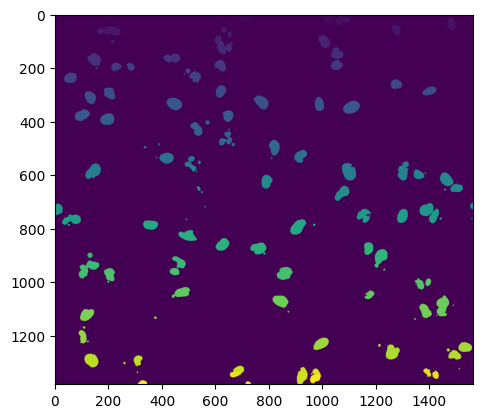

In [9]:
plt.imshow(masks)

In [5]:
import sys
sys.path.append('../')
import microdet.evaluation

# Remove sizes > 100

In [16]:
MICRON_AREA_THRESHOLD = 100
labels = skimage.morphology.label(masks)
micron_labels = []
for i in range(1, len(np.unique(labels))):
    area = np.sum(labels == i)
    if area < MICRON_AREA_THRESHOLD: # 50
        micron_labels.append(i)
micro_mask = np.zeros_like(masks)
for i in micron_labels:
    micro_mask += (labels == i)

In [17]:
micron_labels

[4,
 27,
 31,
 46,
 52,
 53,
 57,
 58,
 67,
 68,
 74,
 75,
 79,
 84,
 86,
 87,
 88,
 91,
 92,
 98,
 107,
 110,
 117,
 119,
 120,
 121,
 122,
 123,
 126,
 128,
 134,
 137,
 141,
 144]

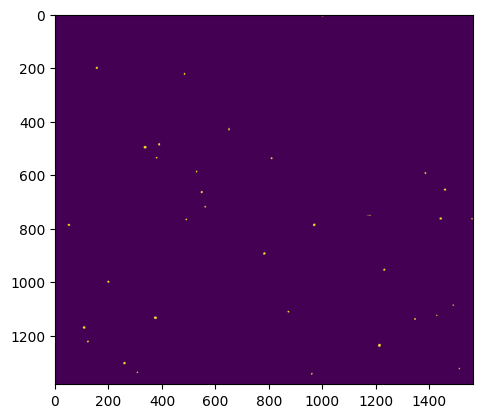

In [18]:
plt.imshow(micro_mask)

In [19]:
microdet.evaluation.segmentation_report(imid='2022-05-26_RPE1-2198', predictions=micro_mask, gt=gt, intersection_ratio=0.1, report_obj='Micronuclei')

2022-05-26_RPE1-2198,0.9706,0.2920


Error: You must call wandb.init() before wandb.log()